# Adaptive QCNN, solving clf problem - dataset: MNIST

## Install / Update packages

In [1]:
a = 1
print(1)

1


In [2]:
# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install scikit-learn
# %pip install pylatexenc

# %pip install qiskit==1.2.4
# %pip install qiskit_aer==0.15.1
# # %pip install qiskit_algorithms
# %pip install qiskit_ibm_runtime==0.29.0
# %pip install qiskit_machine_learning==0.8.1

# %pip install pennylane==0.39.0
# %pip install pennylane_qiskit==0.39.1

# %pip install torch==2.5.0
# %pip install torchvision==0.20.0
# %pip install tensorflow==2.17.0

In [3]:
import random
import numpy as np

import qiskit
import qiskit_ibm_runtime
import qiskit_machine_learning
import qiskit_aer

# import pennylane as qml
# import pennylane_qiskit
# from pennylane import numpy as pnp

import torch
import torchvision
import tensorflow as tf

In [4]:
print("Packge version:")
print("  qiskit:", qiskit.__version__)
print("  qiskit-ibm-runtime:", qiskit_ibm_runtime.__version__)
print("  qiskit-machine-learning:", qiskit_machine_learning.__version__)
print("  qiskit-Aer:", qiskit_aer.__version__)
print("")
# print("  pennylane:", qml.__version__)
# print("  pennylane-qiskit:", pennylane_qiskit.__version__)
print("")
print("  torch:", torch.__version__)
print("  torchvision:", torchvision.__version__)
print("  tensorflow:", tf.__version__)

Packge version:
  qiskit: 1.2.4
  qiskit-ibm-runtime: 0.29.0
  qiskit-machine-learning: 0.8.1
  qiskit-Aer: 0.15.1


  torch: 2.5.0+cpu
  torchvision: 0.20.0+cpu
  tensorflow: 2.17.0


## Preparing Simulation Setups:

### Load your IBM account with instance, and quantum backend

In [5]:
# Select the backend of your choice. If None, the least busy backend will be selected.
# AVAILABLE BACKEND: 
# instance: 'ibm-q-yonsei/internal/default' -> ibm_brussels, ibm_fez, ibm_strasbourg, ibm_sherbrooke, ibm_brisbane, ibm_nazca, ibm_torino, ibm_kyiv,
# instance: 'yonsei-dedicated/researchyonsei/d-parklab' -> ibm_yonsei

# backend_select = None
# backend_select = "ibm_nazca"
backend_select = "ibm_yonsei"

# if backend_select == None:
#     backend = service.least_busy(operational=True, simulator=False)
# else:
#     backend = service.backend(backend_select)
# print('backend:', backend)

In [6]:
# Choose quantum backend
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2
from qiskit_ibm_runtime import QiskitRuntimeService

def choose_backend(noise_setting, backend_select = None, num_shots = 1024):
    # Declare ibm quantum service
    if backend_select == 'ibm_yonsei':
        # instance = 'yonsei-dedicated/researchyonsei/d-parklab'
        name = 'yonsei_qdna'
    else:
        # instance = 'ibm-q-yonsei/internal/default'
        name = 'yonsei_internal'
    # Load qiskit runtime service
    service = QiskitRuntimeService()

    # Assign quantum backend
    if noise_setting == '0':
        backend = AerSimulator()
    elif noise_setting == '1':
        backend = FakeGuadalupeV2()
    elif noise_setting == '2':
        if backend_select == None:
            backend = AerSimulator.from_backend(service.least_busy(operational = True, simulator = False))
        else:
            backend = AerSimulator.from_backend(service.backend(backend_select))
    elif noise_setting == '3':
        if backend_select == None:
            backend = service.least_busy(operational = True, simulator = False)
        else:
            backend = service.backend(backend_select)
    
    # Assign number of shots
    backend.options.shots = num_shots
    
    return service, backend

### SIMULATION HYPERPARAMETERS TO CHANGE

In [7]:
# Noise setting and dataset name
noise_setting = '3'

# Number of qubits
num_qubits = 4      # 4, 8, 10

# Problem and dataset
problem_type = 'clf'
dataset_type = 'mnist'
dataset_dir = None
dataset_name = 'mnist'

# device name
noise_to_device = {'0': 'noiseless',
                   '1': 'FakeGuadalupeV2',
                   '2': 'AerSim_with_backend_noise',
                   '3': 'IBM_Quantum_backend'}
device_name = noise_to_device.get(noise_setting, 'UnknownDevice')

# IBM service and backend
num_shots = 256
service, backend = choose_backend(noise_setting = noise_setting,
                                  backend_select = backend_select,
                                  num_shots = num_shots)

print('noise_setting:', noise_setting)
print('num_qubits:', num_qubits)
print('device_name:', device_name)
print("service:", service)
print("backend:", backend)
print('dataset_name:', dataset_name)

noise_setting: 3
num_qubits: 4
device_name: IBM_Quantum_backend
service: <QiskitRuntimeService>
backend: <IBMBackend('ibm_yonsei')>
dataset_name: mnist


In [8]:
# RNG seed_num setting
sim_iter_num = 0

seed_num_list = [42, 123, 9876, 654, 777]
#                    [0,  1,     2,   3,     4,    5,   6,   7,    8,    9]
# seed_num_list_old= [42, 123, 9876, 101, 876543, 101, 654, 777, 567896, 8888]
# new_seeds_set = [7, 17, 29, 73, 101, 211, 313, 523, 947, 2027]
seed_num = seed_num_list[sim_iter_num]

print('sim_iter_num:', sim_iter_num)
print('seed_num:', seed_num)

sim_iter_num: 0
seed_num: 42


In [9]:
# Define function to fix the random seed number
from qiskit_machine_learning.utils import algorithm_globals

def set_seed(seed):
    random.seed(seed)
    
    np.random.seed(seed)
    
    # qml.numpy.random.seed(seed)
    
    algorithm_globals.random_seed = seed
        
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # If using multi-GPU.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    tf.random.set_seed(seed)

set_seed(seed_num)

### Create Result Folder
- This code creates a folder to save our model's results.
- If the folder doesn't exist, it makes one.
    - `result_folder_name`: string. name of the folder to be saved.

In [10]:
# Define the folder name
### EDITED FOR REVIEW FEEDBACK ###
save_dir = f'save_results_fb_{problem_type}/{dataset_name}_{num_qubits}/'
### EDITED FOR REVIEW FEEDBACK ###

# Create the folder if it doesn't exist
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
print('save_dir:', save_dir)

save_dir: save_results_fb_clf/mnist_4/


## Load the dataset: MNIST dataset

### SUBSET THE DATASET IF NEEDED TO CHANGE

In [11]:
# ############# Subset the dataset if needed ############# (reduce the dataset size)
n_train_size = 200          # len(data_train)
n_val_size = 40             # len(data_val)
n_test_size = 200           # len(data_test)

batch_size = 10
# ########################################################

In [12]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch import manual_seed, tensor, float32
from torch.utils.data import TensorDataset

from sklearn.decomposition import PCA
import tensorflow as tf
def dim_reduction(loader, dim_reduct):
    loader.data = loader.data[..., np.newaxis] / 255.0
    loader.data = tf.image.resize(loader.data, (256, 1)).numpy()
    loader.data = tf.squeeze(loader.data).numpy()
    loader.data = PCA(dim_reduct).fit_transform(loader.data)
    for i, x in enumerate(loader.data):
        loader.data[i] = (x - x.min()) * (np.pi / (x.max() - x.min()))
    
    loader.data = tensor(loader.data, dtype=float32)

    return loader

In [13]:
# Train Dataset
# -------------

# Set train shuffle seed (for reproducibility)
# manual_seed(torch_seed_num)

# We will concentrate on the first 'n_samples' (per class)
n_samples_train = int(n_train_size / 2)  
n_samples_val = int(n_val_size / 2)

# Use pre-defined torchvision function to load MNIST train data
X_train = datasets.MNIST(
    root="./data",
    train = True,
    download = True,
    transform = transforms.Compose([transforms.ToTensor()])
)

X_val = datasets.MNIST(
    root="./data",
    train = True,
    download = True,
    transform = transforms.Compose([transforms.ToTensor()])
)

# Filter out labels (originally 0-9), leaving only labels 0 and 1
idx_train = np.append(
    np.where(X_train.targets == 0)[0][:n_samples_train],
    np.where(X_train.targets == 1)[0][:n_samples_train]
    )

idx_val = np.append(
    np.where(X_train.targets == 0)[0][n_samples_train:(n_samples_train + n_samples_val)],
    np.where(X_train.targets == 1)[0][n_samples_train:(n_samples_train + n_samples_val)]
    )

X_train.data = X_train.data[idx_train]
X_train.targets = X_train.targets[idx_train]

X_val.data = X_val.data[idx_val]
X_val.targets = X_val.targets[idx_val]

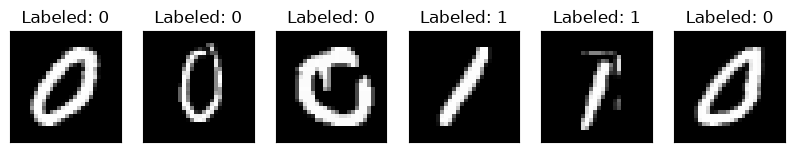

In [14]:
import matplotlib.pyplot as plt

n_samples_show = 6

data_iter = iter(DataLoader(X_train, batch_size=1, shuffle=True))
fig, axes = plt.subplots(nrows=1, ncols=n_samples_show, figsize=(10, 3))

while n_samples_show > 0:
    images, targets = data_iter.__next__()

    axes[n_samples_show - 1].imshow(images[0, 0].numpy().squeeze(), cmap="gray")
    axes[n_samples_show - 1].set_xticks([])
    axes[n_samples_show - 1].set_yticks([])
    axes[n_samples_show - 1].set_title("Labeled: {}".format(targets[0].item()))

    n_samples_show -= 1

In [15]:
# Dimension Reduction using PCA
train_dataset = dim_reduction(X_train, num_qubits)
val_dataset = dim_reduction(X_val, num_qubits)

# Define torch dataloader with filtered data
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)

In [16]:
# Test Dataset
# -------------

# We will concentrate on the first 'n_samples' (per class)
n_samples_test = int(n_test_size / 2)

# Use pre-defined torchvision function to load MNIST test data
X_test = datasets.MNIST(
    root="./data",
    train = False,
    download = True,
    transform=transforms.Compose([transforms.ToTensor()])
)

# Filter out labels (originally 0-9), leaving only labels 0 and 1
idx = np.append(
    np.where(X_test.targets == 0)[0][:n_samples_test],
    np.where(X_test.targets == 1)[0][:n_samples_test]
)
X_test.data = X_test.data[idx]
X_test.targets = X_test.targets[idx]

test_dataset = dim_reduction(X_test, num_qubits)

# Define torch dataloader with filtered data
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

In [17]:
# Print some information about the loaded and processed data
print(f"Training data shape: {X_train.data.shape}")
print(f"Training data type: {type(X_train.data)}")
print(f"Validation data shape: {X_val.data.shape}")
print(f"Training data type: {type(X_val.data)}")
print(f"Test data shape: {X_test.data.shape}")
print(f"Test data type: {type(X_test.data)}")
print()
print(f"Number of training samples: {len(X_train.data)}")
print(f"Number of validation samples: {len(X_val.data)}")
print(f"Number of test samples: {len(X_test.data)}")
print()

# Verify the unique labels
print(f"Unique labels in training set: {np.unique(X_train.targets)}")
print(f"Unique labels in test set: {np.unique(X_test.targets)}")

Training data shape: torch.Size([200, 4])
Training data type: <class 'torch.Tensor'>
Validation data shape: torch.Size([40, 4])
Training data type: <class 'torch.Tensor'>
Test data shape: torch.Size([200, 4])
Test data type: <class 'torch.Tensor'>

Number of training samples: 200
Number of validation samples: 40
Number of test samples: 200

Unique labels in training set: [0 1]
Unique labels in test set: [0 1]


In [18]:
def count_labels_from_targets(targets, dataset_name="Dataset"):
    unique, counts = torch.unique(targets, return_counts=True)
    total = len(targets)
    print(f"\n{dataset_name} Label Counts:")
    for label, count in zip(unique.tolist(), counts.tolist()):
        ratio = count / total * 100
        print(f"  Label {label}: {count} ({ratio:.4f}%)")

# Call the function for X_train.targets
count_labels_from_targets(X_train.targets, "X_train Dataset")
count_labels_from_targets(X_val.targets, "X_val Dataset")
count_labels_from_targets(X_test.targets, "X_test Dataset")


X_train Dataset Label Counts:
  Label 0: 100 (50.0000%)
  Label 1: 100 (50.0000%)

X_val Dataset Label Counts:
  Label 0: 20 (50.0000%)
  Label 1: 20 (50.0000%)

X_test Dataset Label Counts:
  Label 0: 100 (50.0000%)
  Label 1: 100 (50.0000%)


## Buid Quantum Circuit using IBM Quantum / Qiskit

### Build the QCNN circuits

In [19]:
# num_qubits = 8
num_input = X_train.data.shape[1]

print('num_qubits:', num_qubits)
print('num_input:', num_input)

num_qubits: 4
num_input: 4


In [20]:
########## QCNN blocks for circuit ##########
# Data Embedding: Angle Embedding
import copy
from qiskit.circuit import QuantumRegister, ClassicalRegister, QuantumCircuit, ParameterVector
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.circuit.library import QNNCircuit

# Angle Embedding
def AngleEmbedding(num_feature):
    embed_param = ParameterVector(name = 'x', length = num_feature)
    embedding = QuantumCircuit(num_feature, name = 'AngleEmbedding')
    for i in range(num_feature):
        embedding.ry(embed_param[i], qubit = i)
    embedding = embedding.to_instruction()

    qc = QuantumCircuit(num_feature, name = 'AngleEmbedding')
    qc.append(instruction = embedding, qargs = range(num_feature))
    return qc

def AngleEmbedding_reverse(num_feature):
    embed_param = ParameterVector(name = 'x', length = num_feature)
    embedding = QuantumCircuit(num_feature, name = 'AngleEmbedding-r')
    for i in range(num_feature):
        embedding.ry(embed_param[num_feature - 1 - i], qubit = i)
    embedding = embedding.to_instruction()

    qc = QuantumCircuit(num_feature, name = 'AngleEmbedding-r')
    qc.append(instruction = embedding, qargs = range(num_feature))
    return qc

# Convolution blocks
def ConvSimple(param):
    qc = QuantumCircuit(2, name = "Conv_Simple")
    qc.ry(theta = param[0], qubit = 0)
    qc.ry(theta = param[1], qubit = 1)
    qc.cx(control_qubit = 0, target_qubit = 1)
    gate = qc.to_gate()
    return gate

def ConvSU4(param):
    qc = QuantumCircuit(2, name = "Conv_SU4")
    qc.u(theta = param[0], phi = param[1], lam = param[2], qubit = 0)
    qc.u(theta = param[3], phi = param[4], lam = param[5], qubit = 1)
    qc.cx(control_qubit = 0, target_qubit = 1)
    qc.ry(theta = param[6], qubit = 0)
    qc.rz(phi = param[7], qubit = 1)
    qc.cx(control_qubit = 1, target_qubit = 0)
    qc.ry(theta = param[8], qubit = 0)
    qc.cx(control_qubit = 0, target_qubit = 1)
    qc.u(theta = param[9], phi = param[10], lam = param[11], qubit = 0)
    qc.u(theta = param[12], phi = param[13], lam = param[14], qubit = 1)
    gate = qc.to_gate()
    return gate

# Pooling blocks
def PoolSimple(param):
    qc = QuantumCircuit(2, name = "Pool_Simple")
    qc.crz(theta = param[0], control_qubit = 0, target_qubit = 1, ctrl_state = '1')
    qc.crx(theta = param[1], control_qubit = 0, target_qubit = 1, ctrl_state = '0')
    gate = qc.to_gate()
    return gate

# QCNN circuit: output Feature map
def QCNN_FeatureMap(num_qubits, embed_method):
    if embed_method == 'AngleEmbed':
        feature_map = AngleEmbedding(num_qubits)
    elif embed_method == 'AngleEmbed-r':
        feature_map = AngleEmbedding_reverse(num_qubits)
    elif embed_method == 'ZZFeatureMap':
        feature_map = ZZFeatureMap(num_qubits)
    feature_map.barrier()
    return feature_map

# Measure a qubit with a given basis
def measure_basis(qc, qubit, cbit, meas_basis):
    qc.barrier()
    if meas_basis == 'X':
        qc.h(qubit)
    elif meas_basis == 'Y':
        qc.sdg(qubit)
        qc.h(qubit)
    elif meas_basis == 'Z':
        pass
    qc.measure(qubit, cbit)
    qc.barrier()
    ## Add barrior for mid-circuit measurement.
    ## However, 'StatevectorSampler' cannot handle mid-circuit measurement.

In [21]:
# QCNN circuit: output Ansatz with Measurements
def QCNN_Ansatz_Meas(num_qubits, conv_block = 'ConvSimple', pool_block = 'PoolSimple',
                     multi_meas = False, meas_basis = 'Z', no_boundary = False):  
    # Total number of model parameters (weights) of QCNN
    # if np.log2(num_qubits) != int(np.log2(num_qubits)):
    #     raise ValueError("The n_qubit value must be a power of 2.")
    
    ## circuit parameter
    # conv_param = (number of parameters of the conv_block) * (number of layers)
    # pool_param = (number of parameters of the pool_block) * (number of layers)
    block_param_dict = {'ConvSimple': 2, 'ConvSU4': 15, 'PoolSimple': 2, None: 0}
    num_conv_param = block_param_dict[conv_block]
    num_pool_param = block_param_dict[pool_block] if pool_block else 0
    layer_num = 0
    layer_num_last = int((np.ceil(np.log2(num_qubits))))
    total_param_len = (num_conv_param + num_pool_param) * layer_num_last
    weight_param = ParameterVector(name = 'θ', length = total_param_len)
    
    ## Ansatz and Measurements
    block_index = list(range(num_qubits))
    ansatz_blocks = {'ConvSimple': ConvSimple, 'ConvSU4': ConvSU4, 'PoolSimple': PoolSimple}
    conv_func = ansatz_blocks[conv_block]
    pool_func = ansatz_blocks[pool_block] if pool_block else None
       
    q_reg = QuantumRegister(size = num_qubits, name = 'q')
    ansatz = QuantumCircuit(q_reg, name = 'QCNN_Ansatz')
    if not multi_meas:
        output_dim = 1
    else:
        output_dim = int(np.ceil(np.log2(num_qubits)))
    c_reg = ClassicalRegister(size = output_dim, name = 'c')
    ansatz.add_register(c_reg)
    
    ## QCNN circuit build with mid-circuit measurements
    if not (num_qubits == 8 and pool_block is None and no_boundary):
        ### For len(block_index) > 2:
        while len(block_index) > 2:
            layer_num += 1
            ## Convolution and Pooling
            conv_index = (layer_num - 1) * num_conv_param
            pool_index = layer_num_last * num_conv_param + (layer_num - 1) * num_pool_param
            
            for i in range(0, len(block_index), 2):
                if i + 1 >= len(block_index) and no_boundary:
                    continue           
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1) % len(block_index)]])
            for i in range(1, len(block_index), 2):
                if i + 1 >= len(block_index) and no_boundary:
                    continue             
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1) % len(block_index)]])
            if pool_func is not None:
                if len(block_index) % 2 == 0:
                    len_pool = len(block_index)
                else:
                    len_pool = len(block_index) - 1
                
                for j in range(0, len_pool, 2):
                    if no_boundary and j + 1 >= len(block_index):
                        continue
                    ansatz.append(pool_func(param = weight_param[pool_index:(pool_index + num_pool_param)]),
                                  qargs = [block_index[j], block_index[(j + 1) % len(block_index)]])
            ## Measurement
            if multi_meas:
                measure_basis(qc = ansatz,
                              qubit = q_reg[block_index[0]], 
                              cbit = c_reg[layer_num - 1],
                              meas_basis = meas_basis)
            ## Update block_index
            if len(block_index) % 2 == 0:
                block_index = block_index[1::2]
            else:
                block_index = block_index[1::2] + [block_index[-1]]
                            
        ### For len(block_index) == 2:
        layer_num += 1
        ## Convolution and Pooling
        conv_index = (layer_num - 1) * num_conv_param
        pool_index = layer_num_last * num_conv_param + (layer_num - 1) * num_pool_param
        ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                    qargs = [block_index[0], block_index[1]])
        if pool_func is not None:
            ansatz.append(pool_func(param = weight_param[pool_index:(pool_index + num_pool_param)]),
                          qargs = [block_index[0], block_index[1]])
        ## Measurement
        measure_basis(qc = ansatz, 
                      qubit = q_reg[block_index[-1]], 
                      cbit = c_reg[layer_num - 1] if multi_meas else c_reg[0],
                      meas_basis = meas_basis)
        
    ## Exceptional conditions to create a specific circuit
    elif (num_qubits == 8 and pool_block is None and no_boundary):
        ### For the first layer ###
        layer_num += 1
        ## Convolution only
        conv_index = (layer_num - 1) * num_conv_param
        for i in range(0, len(block_index)):
            if i < len(block_index) // 2:
                j = 2 * i       # even index part
            else:
                j = 2 * (i - len(block_index) // 2) + 1  # odd index part
            if no_boundary and j + 1 >= len(block_index):
                continue
            ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                          qargs = [block_index[j], block_index[(j + 1) % len(block_index)]])
        ## Measurement
        if multi_meas:
            measure_basis(qc = ansatz,
                          qubit = q_reg[block_index[0]], 
                          cbit = c_reg[layer_num - 1],
                          meas_basis = meas_basis)
        block_index = block_index[2:(len(block_index)-2)]
        
        ### After the first layer, and For len(block_index) > 2
        while len(block_index) > 2:
            layer_num += 1
            ## Convolution only
            conv_index = (layer_num - 1) * num_conv_param
            for i in range(0, len(block_index), 2):
                ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                              qargs = [block_index[i], block_index[(i + 1)]])
            ## Measurement
            if multi_meas:
                q_reg_to_measure = q_reg[block_index[1]] if layer_num == 3 else q_reg[block_index[0]]
                measure_basis(qc = ansatz,
                                qubit = q_reg_to_measure, 
                                cbit = c_reg[layer_num - 1],
                                meas_basis = meas_basis)
            block_index = block_index[1:(len(block_index)-1)]
        
        ### For len(block_index) == 2:
        layer_num += 1
        ## Convolution only
        conv_index = (layer_num - 1) * num_conv_param
        for i in range(0, len(block_index), 2):
            ansatz.append(conv_func(param = weight_param[conv_index:(conv_index + num_conv_param)]),
                            qargs = [block_index[i], block_index[(i + 1)]])
        ## Measurement
        measure_basis(qc = ansatz, 
                      qubit = q_reg[block_index[-1]], 
                      cbit = c_reg[layer_num - 1] if multi_meas else c_reg[0],
                      meas_basis = meas_basis)

    if noise_setting == '0':
        return ansatz
    else:
        ansatz = ansatz.to_instruction()
        # q_reg = QuantumRegister(size = num_qubits, name = 'q')
        # c_reg = ClassicalRegister(size = output_dim, name = 'c')
        qc = QuantumCircuit(q_reg, c_reg, name = 'QCNN_Ansatz')
        qc.append(instruction = ansatz, qargs = q_reg, cargs = c_reg)
        return qc

def QCNN_Ansatz_list(num_qubits, conv_block = 'ConvSimple', pool_block = 'PoolSimple',
                     multi_meas = False, multi_basis = False, no_boundary = False):
    # Case 1
    if not multi_meas and not multi_basis:
        ansatz = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                         multi_meas = False, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz.name = 'QCNN_Ansatz_trad'
        return [ansatz]
    
    # Case 2
    elif multi_meas and not multi_basis:
        ansatz_Z = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                         multi_meas = True, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz_Z.name = 'QCNN_Ansatz_Z'
        return [ansatz_Z]
    
    # Case 3
    elif multi_meas and multi_basis:
        ansatz_X = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'X', no_boundary = no_boundary)
        ansatz_X.name = 'QCNN_Ansatz_X'
        ansatz_Y = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'Y', no_boundary = no_boundary)
        ansatz_Y.name = 'QCNN_Ansatz_Y'
        ansatz_Z = QCNN_Ansatz_Meas(num_qubits, conv_block = conv_block, pool_block = pool_block,
                                  multi_meas = True, meas_basis = 'Z', no_boundary = no_boundary)
        ansatz_Z.name = 'QCNN_Ansatz_Z'
        return [ansatz_X, ansatz_Y, ansatz_Z]

In [22]:
# QCNN circuit parameters
def qcnn_circuit_param(n_qubit, conv_block, pool_block, multi_meas, multi_basis):
    conv_param = 0
    pool_param = 0
    # Total number of model parameters (weights) of QCNN
    # if np.log2(n_qubit) != int(np.log2(n_qubit)):
    #     raise ValueError("The n_qubit value must be a power of 2.")
    
    # conv_param = (number of parameters of the conv_block) * (number of layers)
    # pool_param = (number of parameters of the pool_block) * (number of layers)
    if conv_block == 'ConvDefault':
        conv_param = 3 * int(np.log2(n_qubit))
    elif conv_block == 'ConvSimple':
        conv_param = 2 * int(np.log2(n_qubit))
    elif conv_block == 'ConvSU4':
        conv_param = 15 * int(np.log2(n_qubit))
        
    if pool_block == 'PoolDefault':
        pool_param = 3 * int(np.log2(n_qubit))
    elif pool_block == 'PoolSimple':
        pool_param = 2 * int(np.log2(n_qubit))
    
    total_param_num = conv_param + pool_param
    
    # weight shape / initial weights of QCNN
    weight_shapes = {"params": total_param_num}
    weight = [random.uniform(0, 1) for _ in range(total_param_num)]
    
    # Output dimension of QCNN
    if multi_meas == True:
        output_dim = int(np.log2(n_qubit))
    else:
        output_dim = 1
        
    # if multi_basis == True:
    #     output_dim = 3 * output_dim
    # else:
    #     output_dim = output_dim
    return total_param_num, weight_shapes, weight, output_dim

In [23]:
def num_measurement_total(num_qubits, multi_meas, multi_basis):
    if multi_meas == False:
        num_meas_for_each_circ = 1
        num_meas_total = num_meas_for_each_circ
    elif (multi_meas, multi_basis) == (True, False):
        num_meas_for_each_circ = int(np.ceil(np.log2(num_qubits)))
        num_meas_total = num_meas_for_each_circ
    elif (multi_meas, multi_basis) == (True, True):
        num_meas_for_each_circ = int(np.ceil(np.log2(num_qubits)))
        num_meas_total = 3 * num_meas_for_each_circ
    return num_meas_for_each_circ, num_meas_total

def model_name_strings(multi_meas, multi_basis):
    if multi_meas == False:
        str = 'model_mmF'
    elif (multi_meas, multi_basis) == (True, False):
        str = 'model_mmTmbF'
    elif (multi_meas, multi_basis) == (True, True):
        str = 'model_mmTmbT'
    return str

In [24]:
# QCNN circuit: output circuits
def QCNN_full_circuit(num_qubits, feature_map, ansatz_list,
                      multi_meas = False, multi_basis = False):
    # Case 1
    if not multi_meas and not multi_basis:
        qc = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc.name = 'QCNN_circ_trad'
        return [qc]
    
    # Case 2
    elif multi_meas and not multi_basis:
        qc = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc.name = 'QCNN_circ_mmTmbF'
        return [qc]
    
    # Case 3
    elif multi_meas and multi_basis:
        qc_x = QNNCircuit(num_qubits, feature_map, ansatz_list[0])
        qc_y = QNNCircuit(num_qubits, feature_map, ansatz_list[1])
        qc_z = QNNCircuit(num_qubits, feature_map, ansatz_list[2])
        qc_x.name = 'QCNN_circ_mmTmbT_X'
        qc_y.name = 'QCNN_circ_mmTmbT_Y'
        qc_z.name = 'QCNN_circ_mmTmbT_Z'
        return [qc_x, qc_y, qc_z]
    
circ_style = {'displaycolor': {'Conv_Simple': ('#0196fe', '#000000'),
                               'Conv_SU4': ('#0196fe', '#000000'),
                               'PoolSimple': ('#fe7e78', '#000000'),
                               'QCNN_Ansatz': ('#40E0D0', '#000000'),
                               'AngleEmbedding': ('#01AB8E', '#000000')}
              }

### QCNN MODEL HYPERPARAMETERS TO CHANGE

In [25]:
# Global parameters of the QCNN circuit
embed_method = 'AngleEmbed'                           # 'ZZFeatureMap', 'AngleEmbed', 'AngleEmbed-r'
conv_block, pool_block = ('ConvSimple', 'PoolSimple')    # ('ConvSimple', 'PoolSimple'), ('ConvSU4', 'PoolSimple'),
                                                      # ('ConvSimple', None), ('ConvSU4', None) 

multi_meas, multi_basis = (True, False)    # (False, False), (True, False), (True, True)
NO_BOUNDARY = False
NO_BOUNDARY_str = '_noBd' if NO_BOUNDARY else ""

num_meas_for_each_circ, num_meas_total = num_measurement_total(
    num_qubits = num_qubits, multi_meas = multi_meas, multi_basis = multi_basis)
model_name_str = model_name_strings(multi_meas = multi_meas, multi_basis = multi_basis)

print('multi_measurement:', multi_meas)
print('num_meas_for_each_circ:', num_meas_for_each_circ)
print('measure_basis:', multi_basis)
print('num_measurements_total:', num_meas_total)
print('model_name_str:', model_name_str)

multi_measurement: True
num_meas_for_each_circ: 2
measure_basis: False
num_measurements_total: 2
model_name_str: model_mmTmbF


In [26]:
quanum_param_num, weight_shapes, weights, qcnn_output_dim = qcnn_circuit_param(
    n_qubit = num_qubits,
    conv_block = conv_block,
    pool_block = pool_block,
    multi_meas = multi_meas,
    multi_basis = multi_basis
    )

print('quanum_param_num:', quanum_param_num)
print('weight_shapes:', weight_shapes)
print('weights:', weights)
print('qcnn_output_dim:', qcnn_output_dim)

quanum_param_num: 8
weight_shapes: {'params': 8}
weights: [0.6394267984578837, 0.025010755222666936, 0.27502931836911926, 0.22321073814882275, 0.7364712141640124, 0.6766994874229113, 0.8921795677048454, 0.08693883262941615]
qcnn_output_dim: 2


FeatureMap name: AngleEmbedding
FeatureMap parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


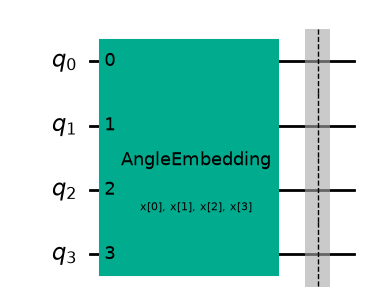

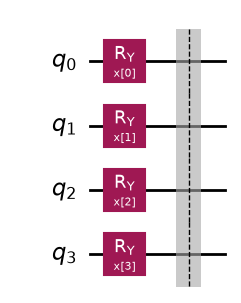

In [27]:
FeatureMap = QCNN_FeatureMap(num_qubits = num_qubits,
                             embed_method = embed_method)
print("FeatureMap name:", FeatureMap.name)
print("FeatureMap parameters:", FeatureMap.parameters)
print("object type:", type(FeatureMap))
display(FeatureMap.draw(output='mpl', style=circ_style))
display(FeatureMap.decompose().draw('mpl'))

Ansatz name: QCNN_Ansatz_Z
Ansatz parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7])])
object type: <class 'qiskit.circuit.quantumcircuit.QuantumCircuit'>


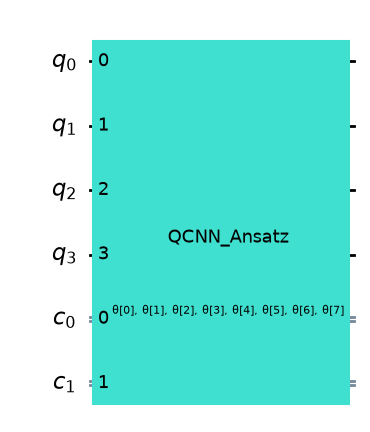

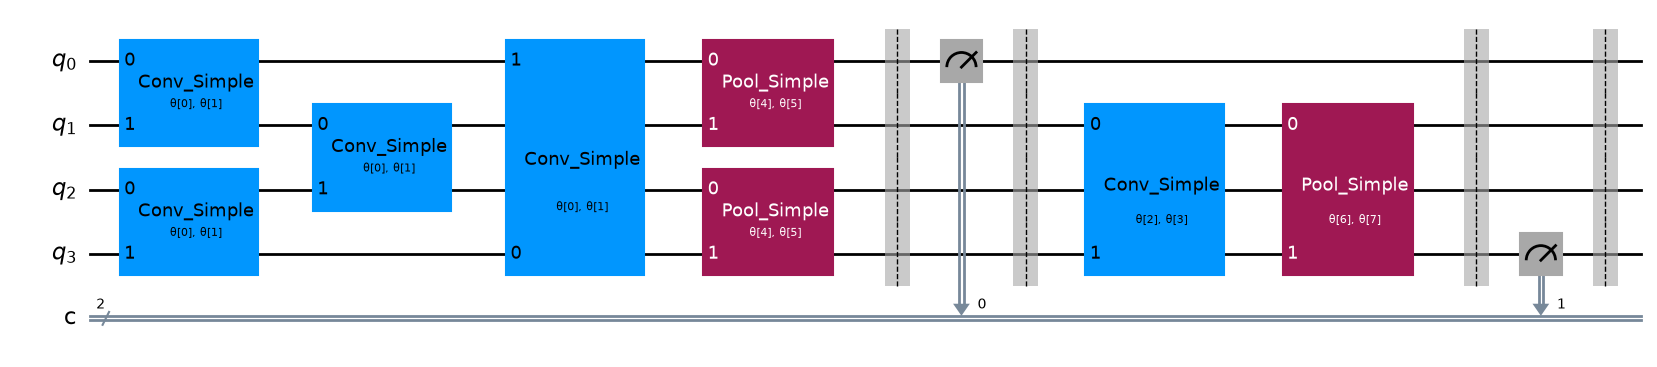

In [28]:
Ansatz_list = QCNN_Ansatz_list(num_qubits = num_qubits,
                               conv_block = conv_block,
                               pool_block = pool_block,
                               multi_meas = multi_meas,
                               multi_basis = multi_basis,
                               no_boundary = NO_BOUNDARY)

for j in range(len(Ansatz_list)):
    print("Ansatz name:", Ansatz_list[j].name)
    print("Ansatz parameters:", Ansatz_list[j].parameters)
    print("object type:", type(Ansatz_list[j]))
    display(Ansatz_list[j].draw(output='mpl', style=circ_style, cregbundle = False))
    display(Ansatz_list[j].decompose(reps=1).draw('mpl', style=circ_style, fold=100))

circuit name: QCNN_circ_mmTmbF
circuit parameters:
  input parameters: ParameterView([ParameterVectorElement(x[0]), ParameterVectorElement(x[1]), ParameterVectorElement(x[2]), ParameterVectorElement(x[3])])
  weight parameters: ParameterView([ParameterVectorElement(θ[0]), ParameterVectorElement(θ[1]), ParameterVectorElement(θ[2]), ParameterVectorElement(θ[3]), ParameterVectorElement(θ[4]), ParameterVectorElement(θ[5]), ParameterVectorElement(θ[6]), ParameterVectorElement(θ[7])])
object type: <class 'qiskit_machine_learning.circuit.library.qnn_circuit.QNNCircuit'>


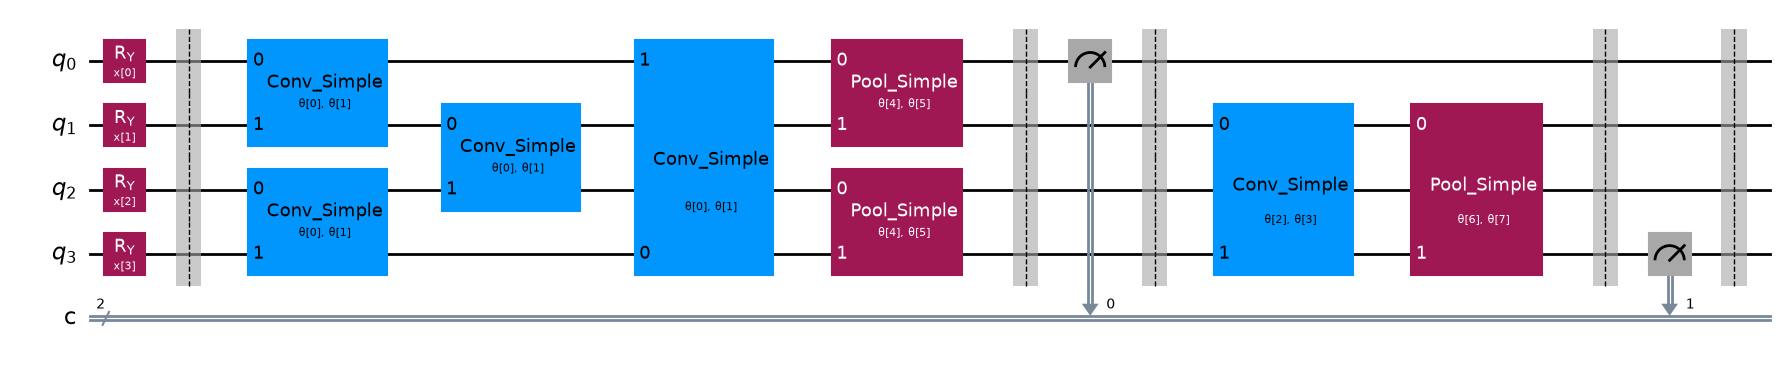

In [29]:
# Plot the QCNN circuit and save it.
SAVE_PLOT_CIRCUIT = False
num_reps = 1    # num_reps = 0, 2

if SAVE_PLOT_CIRCUIT == True:
    # Create the folder if it doesn't exist
    import os
    save_dir_plot = save_dir + 'circuit_plots/'
    if not os.path.exists(save_dir_plot):
        os.makedirs(save_dir_plot)

QCNN_circ = QCNN_full_circuit(num_qubits = num_qubits,
                              feature_map = FeatureMap,
                              ansatz_list = Ansatz_list,
                              multi_meas = multi_meas,
                              multi_basis = multi_basis)

for j in range(len(QCNN_circ)):
    print("circuit name:", QCNN_circ[j].name)
    # print("circuit parameters:", QCNN_circ[j].parameters)
    print("circuit parameters:")
    print("  input parameters:", QCNN_circ[j].input_parameters)
    print("  weight parameters:", QCNN_circ[j].weight_parameters)
    print("object type:", type(QCNN_circ[j]))
    display(QCNN_circ[j].decompose(reps=num_reps).draw('mpl', style=circ_style, fold=100))
    if SAVE_PLOT_CIRCUIT == True:
        plot_savefile = save_dir_plot + f'{QCNN_circ[j].name}_{conv_block}_{pool_block}{NO_BOUNDARY_str}_decomp{num_reps}.png'
        QCNN_circ[j].decompose(reps=num_reps).draw('mpl', style=circ_style, fold=100, cregbundle = False).savefig(plot_savefile, dpi=100, bbox_inches='tight')

In [30]:
# Decompose circuit to avoid any miscellaneous errors
for k in range(len(QCNN_circ)):
    QCNN_circ[k] = QCNN_circ[k].decompose(reps=1)

### Transpile circuit, Sampler, and SamplerQNN

In [31]:
# from qiskit.primitives import StatevectorSampler, StatevectorEstimator
from qiskit_ibm_runtime import Session, Batch, SamplerV2, EstimatorV2, SamplerOptions
from qiskit.primitives import BaseSamplerV2, BackendSamplerV2, BackendEstimatorV2
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.gradients import ParamShiftSamplerGradient, SPSASamplerGradient, ParamShiftEstimatorGradient, SPSAEstimatorGradient
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
# from qiskit_machine_learning.connectors import TorchConnector


# interpret function of SamplerQNN
def null_interpret(x):
    # To define `output_shape` we must also define an `interpret` function,
    # even if it do nothing. If `output_shape` is not defined, the measurement
    # will always return an array with 2^n quasi-probabilities, padding with
    # zeroes the amplitudes not associated with measured qubits.
    return x

def qiskit_session_sampler_pm_gradient_SamplerQNN(noise_setting, backend,
                                                  multi_basis, QCNN_circ, FeatureMap, Ansatz_list,
                                                  num_meas_for_each_circ,
                                                  num_shots = 1024):
    # Session
    session = Session(backend = backend, max_time="100h")
    # session = Batch(backend = backend)
    
    # Sampler, Pass manager
    if noise_setting == '0':
        sampler = SamplerV2(mode = backend)
        # estimator = EstimatorV2(mode = backend)
        pass_manager = None
    elif noise_setting in ['1', '2']:
        # sampler = SamplerV2(mode = backend)
        # sampler = SamplerV2(mode = session)
        
        # options.execution.shots = num_shots
        # sampler = BackendSamplerV2(backend = backend, options = options)
        sampler = BackendSamplerV2(backend = backend, options = {"default_shots": num_shots})
        pass_manager = generate_preset_pass_manager(optimization_level = 3,  backend = backend)
    elif noise_setting == '3':
        # sampler = SamplerV2(mode = backend)
        options = SamplerOptions(default_shots = num_shots)
        sampler = SamplerV2(mode = session, options = options)
        pass_manager = generate_preset_pass_manager(optimization_level = 3, backend = backend)
        
    # Gradient
    sampler_gradient = ParamShiftSamplerGradient(sampler = sampler, pass_manager = pass_manager)
    # sampler_gradient = SPSASamplerGradient(sampler = sampler, pass_manager = pass_manager)
    
    if multi_basis == False:        
        # SamplerQNN
        qcnn_qnn = SamplerQNN(
            circuit = QCNN_circ[0],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[0].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        
        # QNN list
        qnn_list = [qcnn_qnn]
        
    else:
        # SamplerQNN
        qcnn_qnn_X = SamplerQNN(
            circuit = QCNN_circ[0],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[0].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        qcnn_qnn_Y = SamplerQNN(
            circuit = QCNN_circ[1],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[1].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        qcnn_qnn_Z = SamplerQNN(
            circuit = QCNN_circ[2],
            sampler = sampler,
            input_params = FeatureMap.parameters,
            weight_params = Ansatz_list[2].parameters,
            interpret = null_interpret,
            output_shape = 2**num_meas_for_each_circ,
            gradient = sampler_gradient,
            input_gradients = True,
            pass_manager = pass_manager
            )
        
        # QNN list
        qnn_list = [qcnn_qnn_X, qcnn_qnn_Y, qcnn_qnn_Z]
        
    return session, sampler, qnn_list

if noise_setting != '3':
    session, sampler, qnn_list = qiskit_session_sampler_pm_gradient_SamplerQNN(
        noise_setting = noise_setting,
        backend = backend,
        multi_basis = multi_basis,
        QCNN_circ = QCNN_circ,
        FeatureMap = FeatureMap,
        Ansatz_list = Ansatz_list,
        num_meas_for_each_circ = num_meas_for_each_circ,
        num_shots = num_shots
        )

In [32]:
# display(qcnn_qnn_X.circuit.draw('mpl'))

# from qiskit_machine_learning.connectors import TorchConnector
# TorchConnector(qcnn_qnn_X, initial_weights = weights)(X_train_pca.data[0])

## Build Classical Neural Network using PyTorch module

### NN MODEL HYPERPARAMETERS TO CHANGE

In [33]:
# Define the number of epochs, batch size, activation function for the hidden layers and the output layer
import math
from torch.nn import Identity, ReLU, CELU, Sigmoid, Tanh

num_epochs = 10
batch_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
pretraining_ON = False

hidden_acti = ReLU()    # torch.nn.Identity, ReLU, CELU, Sigmoid, Tanh
output_acti = Sigmoid()    # torch.nn.Tanh

# Set the optimizer's learning rate and lr_schedule
lr_value = 0.05
lr_schedule = False
lr_schedule_str = '_schedT' if lr_schedule else ""

# Define the input size and layer size
# input_size = num_meas_total
### EDITED FOR REVIEW FEEDBACK ###
input_size = int(np.ceil(np.log2(num_qubits)))
### EDITED FOR REVIEW FEEDBACK ###
output_size = 1
layer_sizes = (input_size, 3 * input_size, output_size)
# layer_sizes = (input_size, 3 * input_size, 3 * input_size, output_size)
num_hidden_layers = len(layer_sizes) - 2

print('----------Configuration of NN model structure and optimization setting----------')
print('num_epochs:', num_epochs)
print('batch_size:', batch_size)
print('batch_per_epoch:', batch_per_epoch)
print('lr_value:', lr_value)
print('hidden_acti:', hidden_acti)
print('output_acti:', output_acti)
print()
print('input_size:', input_size)
print('layer_sizes:', layer_sizes)
print('num_hidden_layers:', num_hidden_layers)

----------Configuration of NN model structure and optimization setting----------
num_epochs: 10
batch_size: 10
batch_per_epoch: 20
lr_value: 0.05
hidden_acti: ReLU()
output_acti: Sigmoid()

input_size: 2
layer_sizes: (2, 6, 1)
num_hidden_layers: 1


In [34]:
from torch import concat, sum as tsum

def get_counts(x, num_measurements):
    # Calculates the probability of measuring zero on each qubit
    # separately from the measurement probability vector.
    if x.dim() == 1:  # Add batch dimension if missing
        x = x.unsqueeze(0)
        
    #size = 2**(3 * num_measurements)
    size = 2**(num_measurements)

    idx = [v for i, v in enumerate(range(size)) if i % 2 < 1]
    new_x = tsum(x[:,idx], 1, True)

    #for bit in range(1, 3 * num_measurements):
    for bit in range(1, num_measurements):
        idx = [v for i, v in enumerate(range(size)) if i % 2**(bit+1) < 2**bit]
        new_x = concat([new_x, tsum(x[:,idx], 1, True)], 1)

    return new_x

In [35]:
# Define quantum-classical hybrid neural network model
import torch
import torch.nn as nn
from qiskit_machine_learning.connectors import TorchConnector

# Define torch NN module
class QC_Hybrid_Net_v2(nn.Module):
    def __init__(self, qnn_list,
                 layer_sizes, hidden_acti, output_acti,
                 multi_meas = False, multi_basis = False,
                 num_meas_for_each_circ = num_meas_for_each_circ):
        super().__init__()
        self.multi_meas = multi_meas
        self.multi_basis = multi_basis
        self.num_meas_for_each_circ = num_meas_for_each_circ
        
        # Define quantum layer
        # self.q_layer = TorchConnector(qcnn_qnn)
        if self.multi_meas == False:
            self.qlayer_trad = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, False):
            self.qlayer_Z = TorchConnector(qnn_list[0])
        elif (self.multi_meas, self.multi_basis) == (True, True):
            self.qlayer_X = TorchConnector(qnn_list[0])
            self.qlayer_Y = TorchConnector(qnn_list[1])
            self.qlayer_Z = TorchConnector(qnn_list[2])
            
            # Share the parameters between qlayer_X, qlayer_Y, and qlayer_Z
            self._share_weights(self.qlayer_Z, self.qlayer_X, self.qlayer_Y)
        
        # Define classical layers
        ### EDITED FOR REVIEW FEEDBACK ###
        if self.multi_meas == False:
            self.hidden_acti = hidden_acti
            self.output_acti = output_acti
            layers = []
            for i in range(len(layer_sizes) - 2):
                layers.append(nn.Linear(in_features = layer_sizes[i],
                                        out_features = layer_sizes[i + 1]))
                layers.append(self.hidden_acti)
            layers.append(nn.Linear(in_features = layer_sizes[-2],
                                    out_features = layer_sizes[-1]))
            layers.append(self.output_acti)
            self.linear_stack = nn.Sequential(*layers)
        ### EDITED FOR REVIEW FEEDBACK
        
        if self.multi_meas == True:
            self.hidden_acti = hidden_acti
            self.output_acti = output_acti
            layers = []
            for i in range(len(layer_sizes) - 2):
                layers.append(nn.Linear(in_features = layer_sizes[i],
                                        out_features = layer_sizes[i + 1]))
                layers.append(self.hidden_acti)
            layers.append(nn.Linear(in_features = layer_sizes[-2],
                                    out_features = layer_sizes[-1]))
            layers.append(self.output_acti)
            self.linear_stack = nn.Sequential(*layers)
                   
    def forward(self, x):
        if self.multi_meas == False:
            # x = self.qlayer_trad(x)
            # x = get_counts(self.qlayer_trad(x), num_measurements = 1)         
            
            ### EDITED FOR REVIEW FEEDBACK ###
            x1 = get_counts(self.qlayer_trad(x), num_measurements=1)
            target_dim = self.linear_stack[0].in_features
            current_dim = x1.shape[1] 
            padding_size = target_dim - current_dim
            
            if padding_size > 0:
                batch_size = x1.shape[0]
                zeros = torch.zeros(batch_size, padding_size, device=x1.device, dtype=x1.dtype)
                x = torch.cat([zeros, x1], dim=1)
            else:
                x = x1
            x = self.linear_stack(x)
            ### EDITED FOR REVIEW FEEDBACK ###
        elif (self.multi_meas, self.multi_basis) == (True, False):
            x = get_counts(self.qlayer_Z(x), num_measurements = self.num_meas_for_each_circ)
            x = self.linear_stack(x)
        elif (self.multi_meas, self.multi_basis) == (True, True):
            x1 = get_counts(self.qlayer_X(x), num_measurements = self.num_meas_for_each_circ)
            x2 = get_counts(self.qlayer_Y(x), num_measurements = self.num_meas_for_each_circ)
            x3 = get_counts(self.qlayer_Z(x), num_measurements = self.num_meas_for_each_circ)
            x = torch.cat([x1, x2, x3], axis = 1)
            x = self.linear_stack(x)
        return x.reshape(-1)

    
    def _share_weights(self, *layers):
        """Ensure all given quantum layers share the same _parameters dictionary."""
        shared_params = layers[0]._parameters  # Get the _parameters of the first layer
        for layer in layers[1:]:
            layer._parameters = shared_params  # Assign the same _parameters dictionary

    
    def check_shared_parameters(self):
        """Verify that qlayer_X, qlayer_Y, and qlayer_Z share parameters and have identical values."""
        if self.multi_meas and self.multi_basis:
            print("Checking if parameters are shared:")

            # Compare qlayer_X and qlayer_Y
            shared_XY = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y shared: {shared_XY}")

            # Compare qlayer_Y and qlayer_Z
            shared_YZ = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z shared: {shared_YZ}")

            # Compare qlayer_Z and qlayer_X
            shared_ZX = all(
                p1.data_ptr() == p2.data_ptr()
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X shared: {shared_ZX}")

            print("\nChecking if parameter values are identical:")

            # Check if parameter values are identical
            values_XY = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_X.parameters(), self.qlayer_Y.parameters())
            )
            print(f"qlayer_X and qlayer_Y values identical: {values_XY}")

            values_YZ = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Y.parameters(), self.qlayer_Z.parameters())
            )
            print(f"qlayer_Y and qlayer_Z values identical: {values_YZ}")

            values_ZX = all(
                torch.equal(p1, p2)
                for p1, p2 in zip(self.qlayer_Z.parameters(), self.qlayer_X.parameters())
            )
            print(f"qlayer_Z and qlayer_X values identical: {values_ZX}")

        else:
            print("This model doesn't use shared parameters.")

In [36]:
# Instantiate the model for training and evaluation (on test data)
if noise_setting != '3':
    model = QC_Hybrid_Net_v2(
        qnn_list = qnn_list,
        layer_sizes = layer_sizes,
        hidden_acti = hidden_acti,
        output_acti = output_acti,
        multi_meas = multi_meas,
        multi_basis = multi_basis)
    model_eval = QC_Hybrid_Net_v2(
        qnn_list = qnn_list,
        layer_sizes = layer_sizes,
        hidden_acti = hidden_acti,
        output_acti = output_acti,
        multi_meas = multi_meas,
        multi_basis = multi_basis)
    
    model

In [37]:
if noise_setting != '3':
    print(model(X_train.data[0]))
    # print(model(X_train_tensor[0]))
    if (multi_meas, multi_basis) == (True, True):
        model.check_shared_parameters()

## Training the model

### NN MODEL OPTIMIZERS TO CHANGE

In [38]:
# Define model, optimizer, and loss function
from torch.nn import BCELoss, CrossEntropyLoss, MSELoss, NLLLoss
from torch.optim.lr_scheduler import StepLR, MultiStepLR, CosineAnnealingLR

# Optimizer
def optimizer_lrscheduler(model, lr_value, lr_schedule = False,
                          step_size = None, gamma = None, milestone = None):
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr = lr_value,
                                 betas = (0.9, 0.999),
                                 eps = 1e-08,
                                 weight_decay = 0)
    # Learning Rate scheduler
    if lr_schedule:
        # gamma = 0.1
        # step_size = int(num_epochs*0.5)
        # lr_scheduler = StepLR(optimizer, step_size = step_size, gamma = gamma)
        # print(f"Learning rate scheduler initialized with step_size={step_size}, gamma={gamma}.")
        
        # milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
        # lr_scheduler = MultiStepLR(optimizer, milestones = milestone, gamma = gamma)
        # print(f"Learning rate scheduler initialized with gamma = {gamma}.")
        # print('lr_scheduler.milestones:', lr_scheduler.milestones)
        
        lr_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=0.0, last_epoch=-1)
        
    else:
        lr_scheduler = None
        print("Learning rate scheduler is disabled.")
        
    return optimizer, lr_scheduler

if noise_setting != '3':
    if lr_schedule:
        gamma = 0.1
        step_size = int(num_epochs*(0.5))
        milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
    else:
        gamma = None
        step_size = None
        
    optimizer, lr_scheduler = optimizer_lrscheduler(
        model = model,
        lr_value = lr_value,
        lr_schedule = lr_schedule,
        step_size = step_size,
        gamma = gamma
        )
    print('optimizer:', optimizer.__class__.__name__)
    print('Initial lr_value:', lr_value)

# Loss function
loss_func = BCELoss()   # BCELoss(), CrossEntropyLoss, MSELoss()
print('loss_func:', loss_func.__class__.__name__)

loss_func: BCELoss


In [39]:
if noise_setting != '3':
    # Check model parameters
    print("Model Parameters:")
    for name, param in model.named_parameters():
        print(f"Name: {name}, Shape: {param.shape}, Requires Grad: {param.requires_grad}")

    # Check parameter count consistency
    num_model_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    num_optimizer_params = sum(p.numel() for p in optimizer.param_groups[0]['params'])
    print(f"\nNumber of trainable parameters in model: {num_model_params}")
    print(f"Number of parameters in optimizer: {num_optimizer_params}")
    assert num_model_params == num_optimizer_params, "Parameter mismatch between model and optimizer!"

    # Verify loss function and learning rate scheduler
    print(f"\nLoss Function: {loss_func.__class__.__name__}")
    if lr_scheduler:
        print(f"Learning Rate Scheduler: Step Size = {step_size}, Gamma = {gamma}")
    else:
        print("Learning Rate Scheduler: Disabled")

In [40]:
if noise_setting != '3':
    print("Train Data and Targets:")

    for batch, (data, target) in enumerate(train_loader):
        data = data.squeeze()
        target = target.float()
        # target = target.float().unsqueeze(1)
        print('data:', data)
        print('data.shape:', data.shape)
        print('target:', target)
        print('target.shape:', target.shape)
        
        # Pass batch through the model
        output = model(data)  
        print(f"Output: {output}")  # Example output for the batch
        print(f"Target: {target}")  # Example target for the batch

        # Compute loss
        loss = loss_func(output, target)
        print(f"Loss: {loss}")
        
        break  # Remove this line if you want to iterate over all batches

### Create Result Folder - For classical Torch Net results
- This code creates a folder to save our model's results.
- If the folder doesn't exist, it makes one.
    - `save_dir_model`: string. name of the folder to be saved.

In [41]:
import os

# Define the folder name
print('save_dir:', save_dir)
save_dir_model = (f'{save_dir}{model_name_str}/{embed_method}_{conv_block}_{pool_block}{NO_BOUNDARY_str}'
                  +f'_{hidden_acti.__class__.__name__ }_hl{num_hidden_layers}_batch{batch_size}_lr{lr_value}{lr_schedule_str}'
                  +f'/ns{noise_setting}_iter{sim_iter_num}_{num_shots}/')

# Create the folder if it doesn't exist
if not os.path.exists(save_dir_model):
    os.makedirs(save_dir_model)
print('save_dir_model:', save_dir_model)

save_dir: save_results_fb_clf/mnist_4/
save_dir_model: save_results_fb_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.05/ns3_iter0_256/


### Save Qauntum Backend Informtaion and Transpiled Circuit

In [42]:
import os
import pickle

def save_backend_info_with_transpiled_circuit(save_dir_model, noise_setting, backend, qnn_list,
                                              start_epoch, start_batch = 0):
    # Create the folder if it doesn't exist
    
    save_device_info_dir = save_dir_model + f'save_device/'
    if not os.path.exists(save_device_info_dir):
        os.makedirs(save_device_info_dir)
    # print('save_device_info_dir:', save_device_info_dir)
    
    content = []
    content.append(f"Backend: {backend.name}\n")
    content.append(f"Backend Description: {backend.description}\n")
    content.append(f"Backend version: {backend.backend_version}\n")
    if noise_setting != '0':
        content.append(f"Date and time: {backend.properties().to_dict()['qubits'][0][0]['date'].strftime("%Y-%m-%d %H:%M:%S")}\n")
    content.append(f"Num_qubits: {backend.configuration().num_qubits}\n")
    content.append(f"Backend Status: {backend.status}\n")
    content.append(f"Backend Operations:{backend.operations}\n")
    content.append(f"Backend Properties:{backend.properties()}\n")
    content.append(f"Backend Configurations: {backend.configuration()}\n")

    output_file = save_device_info_dir + f'device_info_epoch{start_epoch}_batch{start_batch}.txt'
    with open(output_file, 'w') as file:
        file.writelines(content)
        
    # Save backend configuration and properties
    if noise_setting != '0':
        backend_config = backend.configuration().to_dict()
        backend_properties = backend.properties().to_dict()
        
        # Save to files using pickle
        with open(save_device_info_dir + f'backend_config_epoch{start_epoch}_batch{start_batch}.pkl', 'wb') as f:
            pickle.dump(backend_config, f)
        with open(save_device_info_dir + f'backend_prop_epoch{start_epoch}_batch{start_batch}.pkl', 'wb') as f:
            pickle.dump(backend_properties, f)
            
        # # Load the saved file using pickle
        # with open('backend_config.pkl', 'rb') as f:
        #     loaded_backend_config = pickle.load(f)
        # with open('backend_properties.pkl', 'rb') as f:
        #     loaded_backend_properties = pickle.load(f)
        
    # Save transpiled circuit plot
    for j in range(len(qnn_list)):
        plot_savefile_pm = save_dir_model + f'{QCNN_circ[j].name}_pm_epoch{start_epoch}_batch{start_batch}.png'
        qnn_list[j].circuit.draw('mpl', style=circ_style, fold=200).savefig(plot_savefile_pm, dpi=100, bbox_inches='tight')

if noise_setting not in ['3']:
    save_backend_info_with_transpiled_circuit(
        save_dir_model = save_dir_model,
        noise_setting = noise_setting,
        backend = backend,
        qnn_list = qnn_list,
        start_epoch = num_epochs)

### Training a model

In [43]:
import sys
def append_to_param_history(param_history_path, new_state_dict):
    """
    Efficiently append a new state_dict to param_history.pth.
    
    Args:
        param_history_path (str): Path to the param_history.pth file.
        new_state_dict (dict): The new state_dict to append.
    """
    if os.path.exists(param_history_path):
        try:
            # Load existing history
            param_history = torch.load(param_history_path, weights_only=True)
        except Exception as e:
            print(f"Error loading param_history file: {e}. Initializing a new history.")
            sys.exit("Terminating due to param_history.pth loading error.")
    else:
        param_history = []

    param_history.append(new_state_dict)
    torch.save(param_history, param_history_path)

def recompute_missing_val_loss(train_result_path, param_history_path, model, val_loader, loss_func):
    if not os.path.exists(train_result_path):
        print("No train_results.txt file found. Nothing to recompute.")
        return

    if not os.path.exists(param_history_path):
        print("No param_history.pth file found. Cannot recompute missing val_loss.")
        return

    # Read the train result file
    with open(train_result_path, "r") as f:
        lines = f.readlines()

    header = lines[0].strip()
    # Check if the header includes 'val_loss'
    if 'val_loss' not in header.split(','):
        print("Validation loss column is missing in train_results.txt. Nothing to recompute.")
        return
    results = [line.strip().split(",") for line in lines[1:]]

    # Load param_history
    param_history = torch.load(param_history_path, weights_only=True)

    # Check for missing val_loss and recompute
    updated_results = []
    for row in results:
        if len(row) < 3 or row[2] == '':  # Missing val_loss
            iter_num = int(row[0])
            train_loss = float(row[1])

            if iter_num >= len(param_history):
                print(f"No parameters available for iteration {iter_num}. Skipping recomputation.")
                updated_results.append(row)
                continue

            print(f"Recomputing val_loss for Iteration {iter_num}...")

            # Load the model state for the specific iteration
            model.load_state_dict(param_history[iter_num])

            # Recompute validation loss
            model.eval()
            # val_loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
            total_val_loss = []
            val_loss = 0
            with torch.no_grad():
                for data, target in val_loader:
                    data = data.squeeze()
                    # target = target.float().unsqueeze(1)
                    target = target.float()
                    output = model(data)
                    loss = loss_func(output, target)
                    total_val_loss.append(loss.item())
                val_loss = sum(total_val_loss) / len(total_val_loss)
            print(f"Val_loss for Iteration {iter_num} recomputed: {val_loss:.8f}")
            updated_results.append([iter_num, train_loss, val_loss])
        else:
            updated_results.append(row)

    # Write the updated results back to the file
    with open(train_result_path, "w") as f:
        f.write(header)
        for row in updated_results:
            f.write("\n"+",".join(map(str, row)))

In [44]:
import sys
import copy
import time
from torch.utils.data import DataLoader

def training(model, num_epochs, train_loader,
             optimizer, loss_func, lr_scheduler=None,
             val_loader = None, seed = None, save_dir = None):
    # Set the seed if provided
    if seed is not None:
        set_seed(seed)
        
    # Initialize static, tracking variables, and paths
    start_epoch = 0
    start_batch = 0
    batch_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
    best_val_loss = float('inf') if val_loader else None
    epoch_digit_width = len(str(num_epochs))
    train_result_path = os.path.join(save_dir, 'train_results.txt')
    train_batch_result_path = os.path.join(save_dir, 'train_batch_results.txt')
    checkpoint_path = os.path.join(save_dir, 'model_checkpoint.pth')
    param_history_path = os.path.join(save_dir, 'param_history.pth')
    best_model_state_path = os.path.join(save_dir, 'best_model_state.pth')
                
    # Initialize the train result file if it doesn't exist
    if not os.path.exists(train_result_path):
        with open(train_result_path, "w") as f:
            f.write('epoch,train_loss' + (',val_loss' if val_loader is not None else ""))
    if not os.path.exists(train_batch_result_path):
        with open(train_batch_result_path, "w") as f:
            f.write('epoch,batch,train_batch_loss')
            
    # Resume from checkpoint if available
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, weights_only = True)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        if lr_scheduler is not None:
            if 'lr_scheduler_state_dict' in checkpoint:
                lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])\
        
        start_epoch = checkpoint['epoch']
        start_batch = checkpoint['batch'] + 1
        if start_batch == batch_per_epoch:
            start_epoch += 1
            start_batch = 0
        print(f"Resume training from epoch {start_epoch}, iteration {start_batch}.")
        
        # Recompute missing val_loss
        if val_loader is not None:
            recompute_missing_val_loss(train_result_path, param_history_path, model, val_loader, loss_func)

        # Check if training is already complete
        if start_epoch >= num_epochs:
            print("Training already completed. The model is fully trained.")
    else:
        print("No checkpoint found. Start training model from scratch.")
    
    # Training Loop
    for epoch in range(0, num_epochs):
        # Skip epoch before the resume point
        if epoch < start_epoch:
            continue
        
        model.train()
        start_train_time = time.time()
        total_loss = []
        loss_avg = 0.0
        for batch, (data, target) in enumerate(train_loader):
            # Skip iterations before the resume point
            if batch < start_batch:
                continue
            if batch == start_batch and batch != 0:
                # Load total_loss
                if os.path.exists(checkpoint_path):
                    total_loss = checkpoint['total_loss']
                    # print(f"Loaded total_loss from checkpoint: {total_loss}")

            # Prepare inputs and targets
            data = data.squeeze()
            target = target.float()
            # target = target.float().unsqueeze(1)
            # Training step
            optimizer.zero_grad(set_to_none=True)                   # Initialize gradient
            output = model(data)                                    # Forward pass
            loss = loss_func(output, target)                        # Calculate loss
            loss.backward()                                         # Backward pass
            
            # # Check gradients immediately after backpropagation
            # for name, param in model.named_parameters():
            #     if param.grad is not None:
            #         print(f"{name} - Grad Mean: {param.grad.mean():.4e}, Grad Std: {param.grad.std():.4e}")
            
            optimizer.step()                                        # Optimize weights
            total_loss.append(loss.item())                          # Store loss
            
            # Append to Batch Log file
            with open(train_batch_result_path, "a") as f:
                f.write(f"\n{epoch},{batch},{loss.item()}")

            # Save checkpoint after each iteration
            checkpoint = {
                'epoch': epoch,
                'batch': batch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss.item(),
                'total_loss': total_loss
                }
            torch.save(checkpoint, checkpoint_path)
            
        # Reset start_iteration for subsequent epochs
        start_batch = 0
        
        # Get train duration and loss_avgerage for an epoch 
        train_duration = time.time() - start_train_time
        loss_avg = sum(total_loss) / len(total_loss)
        
        # Append to train result file
        with open(train_result_path, "a") as f:
            f.write(f'\n{epoch},{loss_avg}')
            
        # Update the learning rate scheduler
        if lr_scheduler is not None:
            lr_scheduler.step()
            checkpoint['lr_scheduler_state_dict'] = lr_scheduler.state_dict()
        torch.save(checkpoint, checkpoint_path)
        
        # Save the parameter history
        append_to_param_history(param_history_path, copy.deepcopy(model.state_dict()))
        
        # Validation Phase
        if val_loader is not None:
            model.eval()
            
            start_val_time = time.time()
            total_val_loss = []
            val_loss = 0
            with torch.no_grad():
                for batch, (data, target) in enumerate(val_loader):
                    data = data.squeeze()
                    # target = target.float().unsqueeze(1)
                    target = target.float()
                    output = model(data)
                    loss = loss_func(output, target)
                    total_val_loss.append(loss.item())
                val_duration = time.time() - start_val_time
                val_loss = sum(total_val_loss) / len(total_val_loss)
            
            with open(train_result_path, "a") as f:
                f.write(f',{val_loss}')
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    'best_epoch': epoch,
                    'best_validation_loss': best_val_loss,
                    'best_model_state_dict': copy.deepcopy(model.state_dict())}
                torch.save(best_model_state, best_model_state_path)
        else:
            val_loss, val_duration = None, 0
        
        # Estimate Training End Time
        est_training_end_time = time.strftime("%Y-%m-%d %H:%M:%S",
                                              time.localtime(time.time() + (num_epochs-(epoch + 1))*(train_duration + val_duration)))
        
        # Log training summary per epoch
        summary = (f'Epoch: [{epoch + 1:>{epoch_digit_width}}/{num_epochs}],  '
                    + f'Training Loss: {loss_avg:>10.8f},  '
                    + f'Training Time: {train_duration:>8.2f}s')
        if val_loss is not None:
            summary += (f',  Validation Loss: {val_loss:>10.8f},  '
                        + f'Validation Time: {val_duration:>8.2f}s,  '
                        + f'Estimate. End Time: {est_training_end_time}')
        else:
            summary += (f',  Estimate. End Time: {est_training_end_time}')
        print(summary)

In [ ]:
# Install python-telegram-bot package
# %pip install python-telegram-bot

# Import `telegram` and insert API_KEY and chat_id
from telegram import Bot
from telegram.error import NetworkError, TimedOut
import random
import asyncio

BOT_TOKEN = "MY_BOT_TOKEN" 
CHAT_ID = "MY_CHAT_ID" 

async def send_telegram_message(API_KEY, chat_id, message, max_retries=5):
    bot = Bot(token=API_KEY)
    
    for attempt in range(1, max_retries + 1):
        try:
            await bot.send_message(chat_id=chat_id, text=message)
            print(f"Message sent successfully on attempt {attempt}.")
            return  # Exit function if successful
        except (NetworkError, TimedOut) as e:
            wait_time = random.randint(10, 20)  # Pick a random delay
            print(f"Attempt {attempt} failed: {e}. Retrying in {wait_time} seconds...")
            await asyncio.sleep(wait_time)  # Wait before retrying
    print("Message failed after maximum retries.")
    
err_message = f'Training stopped: ns={noise_setting} | {problem_type} | {dataset_type} | {model_name_str} | sim_iter_num={sim_iter_num}'
succ_message  = f'Training completed: ns={noise_setting} | {problem_type} | {dataset_type} | {model_name_str} | sim_iter_num={sim_iter_num}'

In [46]:
from qiskit_ibm_runtime.exceptions import IBMRuntimeError
from qiskit_machine_learning.exceptions import QiskitMachineLearningError

if noise_setting!='3':
    model_train_results = training(
        model = model,
        num_epochs = num_epochs,
        train_loader = train_loader,
        optimizer = optimizer,
        lr_scheduler = lr_scheduler,
        loss_func = loss_func,
        val_loader = val_loader,
        seed = seed_num,
        save_dir = save_dir_model)
else:
    if pretraining_ON:
        service_pre, backend_pre = choose_backend(noise_setting = '2',
                                                  backend_select = backend_select,
                                                  num_shots = num_shots)
        session_pre, sampler_pre, qnn_list_pre = qiskit_session_sampler_pm_gradient_SamplerQNN(
            noise_setting = '2',
            backend = backend_pre,
            multi_basis = multi_basis,
            QCNN_circ = QCNN_circ,
            FeatureMap = FeatureMap,
            Ansatz_list = Ansatz_list,
            num_meas_for_each_circ = num_meas_for_each_circ,
            num_shots = num_shots
            )
        model = QC_Hybrid_Net_v2(
            qnn_list = qnn_list_pre,
            layer_sizes = layer_sizes,
            hidden_acti = hidden_acti,
            output_acti = output_acti,
            multi_meas = multi_meas,
            multi_basis = multi_basis)
        model_eval = QC_Hybrid_Net_v2(
            qnn_list = qnn_list_pre,
            layer_sizes = layer_sizes,
            hidden_acti = hidden_acti,
            output_acti = output_acti,
            multi_meas = multi_meas,
            multi_basis = multi_basis)
        # Optimizer
        if lr_schedule:
            gamma = 0.1
            step_size = int(num_epochs*(0.5))
            milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
        else:
            gamma = None
            step_size = None
            
        optimizer, lr_scheduler = optimizer_lrscheduler(
            model = model,
            lr_value = lr_value,
            lr_schedule = lr_schedule,
            step_size = step_size,
            gamma = gamma
            )
            
        save_backend_info_with_transpiled_circuit(
            save_dir_model = save_dir_model,
            noise_setting = '2',
            backend = backend_pre,
            qnn_list = qnn_list_pre,
            start_epoch = num_epochs)
            
        model_train_results = training(
            model = model,
            num_epochs = int(num_epochs*0.3),
            train_loader = train_loader,
            optimizer = optimizer,
            lr_scheduler = lr_scheduler,
            loss_func = loss_func,
            val_loader = val_loader,
            seed = seed_num,
            save_dir = save_dir_model)
    else:
        pass
    
    # epoch_interval = 1
    batch_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
    checkpoint_path = os.path.join(save_dir_model, 'model_checkpoint.pth')
    if os.path.exists(checkpoint_path):
        # Load the checkpoint
        checkpoint = torch.load(checkpoint_path, weights_only=True)
        # Retrieve the start_epoch from the checkpoint
        start_epoch = checkpoint['epoch']
        start_batch = checkpoint['batch'] + 1
        if start_batch == batch_per_epoch:
            start_epoch += 1
            start_batch = 0
        remaining_epoch = num_epochs - start_epoch
        print(f"Checkpoint found. Resume training from epoch {start_epoch}, iteration {start_batch}.")
    else:
        start_epoch = 0
        start_batch = 0
        # batch_per_epoch = math.ceil(len(train_loader.dataset) / train_loader.batch_size)
        remaining_epoch = num_epochs
        
    while start_epoch < num_epochs:
        print(f"Training Progress: Start Epoch: {start_epoch}, Start Batch: {start_batch}, Remaining Epochs: {remaining_epoch}, Total Epochs: {num_epochs}")
        try:
            # IBM quantum session and qnn_list
            session, sampler, qnn_list = qiskit_session_sampler_pm_gradient_SamplerQNN(
                noise_setting = noise_setting,
                backend = backend,
                multi_basis = multi_basis,
                QCNN_circ = QCNN_circ,
                FeatureMap = FeatureMap,
                Ansatz_list = Ansatz_list,
                num_meas_for_each_circ = num_meas_for_each_circ,
                num_shots = num_shots
                )
            
            # Build model
            model = QC_Hybrid_Net_v2(
                qnn_list = qnn_list,
                layer_sizes = layer_sizes,
                hidden_acti = hidden_acti,
                output_acti = output_acti,
                multi_meas = multi_meas,
                multi_basis = multi_basis)
            model_eval = QC_Hybrid_Net_v2(
                qnn_list = qnn_list,
                layer_sizes = layer_sizes,
                hidden_acti = hidden_acti,
                output_acti = output_acti,
                multi_meas = multi_meas,
                multi_basis = multi_basis)

            # Optimizer
            if lr_schedule:
                gamma = 0.1
                step_size = int(num_epochs*(0.5))
                milestone = [int(num_epochs*(1/3)), int(num_epochs*(2/3))]
            else:
                gamma = None
                step_size = None
                
            optimizer, lr_scheduler = optimizer_lrscheduler(
                model = model,
                lr_value = lr_value,
                lr_schedule = lr_schedule,
                step_size = step_size,
                gamma = gamma
                )
            
            # Define the folder name
            # print('save_dir:', save_dir)
            # save_dir_model = (f'{save_dir}{model_name_str}/{embed_method}_{conv_block}_{pool_block}'
            #                 +f'_{hidden_acti.__class__.__name__ }_hl{num_hidden_layers}_batch{batch_size}_lr{lr_value}{lr_schedule_str}'
            #                 +f'/ns{noise_setting}_iter{sim_iter_num}_{num_shots}/')

            # Create the folder if it doesn't exist
            if not os.path.exists(save_dir_model):
                os.makedirs(save_dir_model)
            # print('save_dir_model:', save_dir_model)
            
            # Save backend information
            save_backend_info_with_transpiled_circuit(
                save_dir_model = save_dir_model,
                noise_setting = noise_setting,
                backend = backend,
                qnn_list = qnn_list, 
                start_epoch = start_epoch,
                start_batch = start_batch)

            # Train the model for the current interval
            # add_epoch = min(epoch_interval, remaining_epoch)  # Train up to the remaining epochs
            with session:
                training(
                    model = model,
                    num_epochs = num_epochs,
                    train_loader = train_loader,
                    optimizer = optimizer,
                    lr_scheduler = lr_scheduler,
                    loss_func = loss_func,
                    val_loader = val_loader,
                    seed = seed_num,
                    save_dir = save_dir_model
                    )
            session.close()
            
            print("Training completed successfully!")
            # checkpoint = torch.load(os.path.join(save_dir_model, 'model_checkpoint.pth'), weights_only = True)
            start_epoch = num_epochs
            start_batch = 0
            remaining_epoch = num_epochs - start_epoch
            print("start_epoch:", start_epoch)
            print("start_batch:", start_batch)
            print("remaining_epoch:", remaining_epoch)
            break
        
            # if start_epoch >= num_epochs:
            #     print("Training already completed. Exiting loop.")
            #     await send_telegram_message(API_KEY, chat_id, f"{succ_message}")
            #     break  # Exit the loop
        
            # Update epoch tracking variables
            # start_epoch += add_epoch
            # remaining_epoch -= add_epoch
            # print(f"Completed epochs {start_epoch - add_epoch + 1} to {start_epoch}. {remaining_epoch} epochs remaining.")
                
        except (IBMRuntimeError, QiskitMachineLearningError) as e:
            # QiskitMachineLearningError
            # Handle the exception
            print(f"An error occurred: {e}. Attempting to resume.")
            
            # Resume by updating start_epoch and reducing remaining_epoch
            checkpoint = torch.load(os.path.join(save_dir_model, 'model_checkpoint.pth'), weights_only = True)
            
            start_epoch = checkpoint['epoch']
            start_batch = checkpoint['batch'] + 1
            if start_batch == batch_per_epoch:
                start_epoch += 1
                start_batch = 0
            remaining_epoch = num_epochs - start_epoch
            print(f"Session timed out. Resume training from epoch {start_epoch}, iteration {start_batch}.")
            
            # Send Telegram message
            await send_telegram_message(BOT_TOKEN, CHAT_ID, f"{err_message}")

Training Progress: Start Epoch: 0, Start Batch: 0, Remaining Epochs: 10, Total Epochs: 10
Learning rate scheduler is disabled.
No checkpoint found. Start training model from scratch.
An error occurred: 'Sampler job failed: \'Failed to run program: "(\\\'Connection aborted.\\\', ConnectionResetError(10054, \\\'현재 연결은 원격 호스트에 의해 강제로 끊겼습니다\\\'))"\''. Attempting to resume.
Session timed out. Resume training from epoch 0, iteration 6.
Message sent successfully on attempt 1.
Training Progress: Start Epoch: 0, Start Batch: 6, Remaining Epochs: 10, Total Epochs: 10
Learning rate scheduler is disabled.
Resume training from epoch 0, iteration 6.
No param_history.pth file found. Cannot recompute missing val_loss.
Epoch: [ 1/10],  Training Loss: 0.70467357,  Training Time: 12869.27s,  Validation Loss: 0.69323911,  Validation Time:    76.40s,  Estimate. End Time: 2026-08-07 22:02:41
Epoch: [ 2/10],  Training Loss: 0.69378594,  Training Time:  2422.73s,  Validation Loss: 0.69317862,  Validation Time

In [47]:
# for name, param in model.named_parameters():
#     if param.grad is not None:
#         print(f"{name} - Grad Mean: {param.grad.mean():.4e}, Grad Std: {param.grad.std():.4e}")

### Plot the training loss convergence plot

In [48]:
choose_epoch_num = num_epochs

# File path for the log file
train_result_file = save_dir_model + 'train_results.txt'

# Load the file into a pandas DataFrame
import pandas as pd
model_train_results = pd.read_csv(train_result_file)[0:choose_epoch_num]

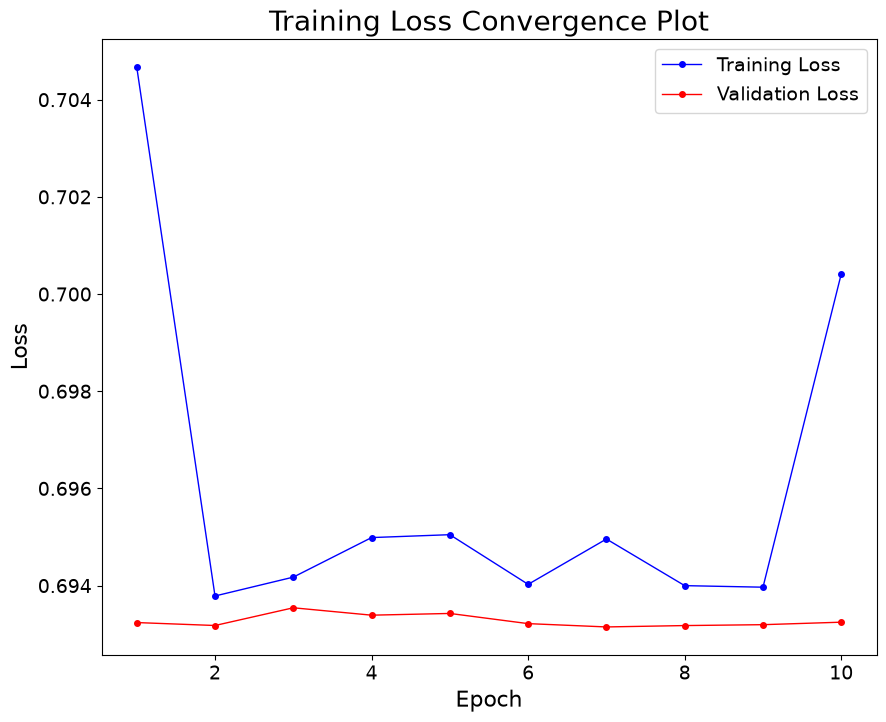

In [49]:
# Plotting the training and validation loss convergence

import matplotlib.pyplot as plt
x_epoch = range(1, len(model_train_results) + 1)
x_tick = range(1, len(model_train_results) + 1, 2)

plt.figure(figsize=(10, 8))
plt.plot(x_epoch, model_train_results['train_loss'], 
         color = 'blue', marker = 'o', markersize = 4, linestyle = '-', linewidth = 1, 
         label = 'Training Loss')
if 'val_loss' in model_train_results:
    plt.plot(x_epoch, model_train_results['val_loss'],
             color='red', marker='o', markersize = 4, linestyle = '-', linewidth = 1,
             label='Validation Loss')

plt.xlabel('Epoch', fontsize = 16)
plt.ylabel('Loss', fontsize = 16)
plt.title('Training Loss Convergence Plot', fontsize = 20)
plt.legend(fontsize = 14)
# plt.xticks(range(0, num_epochs))
# plt.xticks(x_tick)
plt.xticks()
plt.tick_params(axis = 'both', which = 'major', labelsize = 14)
# plt.axhline(y = 0, color='black', linestyle='--', linewidth = 1)
    
# Save the figure
plt.savefig(save_dir_model + f"train_loss_conv_plot_epoch{choose_epoch_num}.png",
            format = 'png', dpi = 300)

# Show the plot
plt.show()

## Testing the PyTorch neural network model
- Using the predefined model object **model_eval**, we evaluate our trained model.

In [50]:
# Load model for evaluation with saved parameters
# param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)
# model_eval.load_state_dict(param_history[choose_epoch_num - 1])

# param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
# print('best_epoch:', param_best['best_epoch'])
# model_eval.load_state_dict(param_best['best_model_state_dict'])

### Evaluate Neural Network Model

- Categorical outcome performance metrics:
    - BCE (binary cross entropy loss): measures the average difference between the predicted probabilities and the actual binary labels.
    $$BCE = -(y \log(\hat{y}) + (1-y)\log(1-\hat{y}))$$
- Numerical outcome perofrmance metrics:
    - MAE (mean absolute error): measures the average of the absolute errors
    $$MAE = \frac{1}{n}\sum_{i=1}^{n}{| Y_i - \hat{Y_i} |}$$

    - MSE (mean squared error): measures the average of the sqaures of the errors
    $$MSE = \frac{1}{n}\sum_{i=1}^{n}{(Y_i - \hat{Y_i})^2}, \quad \text{where } n\text{: num. of data points, } Y\text{: observed values of the variable being predicted, } \hat{Y}\text{: being the predicted values.}$$

    - RMSE (root mean squared error): sqaured root of MSE
    $$RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}{(Y_i - \hat{Y_i})^2}}$$

    - R-squsred (the coefficient of determination):  
    $$R^2 = 1 - \frac{SSE}{SST} = 1 - \frac{\sum_{i=1}^{n}{(Y_i - \hat{Y})^2}}{\sum_{i=1}^{n}{(Y_i - \overline{Y})^2}}$$
    
    - Adjusted R-squared: 
    $$R^2_{adj} = 1 - \frac{SSE / df_{res}}{SST / df_{total}} = 1- (1- R^2)\frac{(n-1)}{(n-p-1)}, \quad \text{where } n\text{: num. of data points, } p\text{: the num. of variables in the model.}$$

In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def model_performance(model, dataset, loss_func):
    model.eval()  # set model to evaluation mode
    data_loader = DataLoader(dataset, batch_size=len(dataset), shuffle = False)
    num_feature = dataset.data.shape[1]
    
    if isinstance(loss_func, torch.nn.MSELoss):
        with torch.no_grad():
            total_loss = 0
            num_samples = 0
            all_targets = []
            all_predictions = []
            
            for data, target in data_loader:
                # Get the predicted target value and the true target value
                data = data.squeeze()
                target = target.float()
                output = model(data)
                pred = output.squeeze()

                # Calculate the loss
                loss = loss_func(pred, target)
                total_loss += loss.item() * data.size(0)
                num_samples += data.size(0)

                # Collect all targets and predictions for further metrics calculation
                all_targets.extend(target.tolist())
                all_predictions.extend(pred.tolist())
                
            # Calculate MSE and R-squared
            y_true = np.array(all_targets)
            y_pred = np.array(all_predictions)
            
            mse_loss = mean_squared_error(y_true=y_true, y_pred=y_pred)
            rmse_loss = np.sqrt(mse_loss)
            mae_loss = mean_absolute_error(y_true=y_true, y_pred=y_pred)
            
            r_squared = r2_score(y_true=y_true, y_pred=y_pred)
            r_sqaured_adj = 1-(1-r_squared)*((len(dataset)-1)/(len(dataset)-num_feature-1))
            
            # Print results
            print('num_samples:', num_samples)
            print(
                "Performance on the given data:\n\tMAE loss: {:.8f}\n\tMSE loss: {:.8f}\n\tRMSE loss: {:.8f}\n\tR-squared: {:.8f}\n\tAdj R-squared: {:.8f}".format(
                    mae_loss, mse_loss, rmse_loss, r_squared, r_sqaured_adj
                )
            )
            
        results = {
            'y_true': y_true,
            'y_pred': y_pred,
            'num_samples': num_samples,
            'mae': mae_loss,
            'mse': mse_loss,
            'rmse': rmse_loss,
            'r-squared': r_squared,
            'adj r-squared': r_sqaured_adj
            }
    
    elif isinstance(loss_func,(torch.nn.BCELoss, torch.nn.CrossEntropyLoss)):
        with torch.no_grad():
            correct = 0
            num_samples = 0
            total_loss = []
            all_targets = []
            all_predictions = []
        
            for data, target in data_loader:
                # Get the predicted target value and the true target value
                data = data.squeeze()
                # Transform labels from -1/1 to 0/1
                y_true = target.clone().detach().float()
                output = model(data).squeeze()
                
                # Get predictions
                y_pred = (output > 0.5).float()
                
                # Calculate the loss
                loss = loss_func(output, y_true)
                total_loss.append(loss.item())
                num_samples += data.size(0)
                
                # Calculate accuracy
                correct += (y_pred == y_true).sum().item()
                
                # Accumulate targets and predictions
                all_targets.append(target)
                all_predictions.append(y_pred)

            cross_entropy_loss = sum(total_loss) / len(total_loss)
            accuracy = 100 * correct / len(data_loader.dataset)
        
            print('num_samples:', num_samples)
            print("Performance on given data:\n\tLoss: {:.4f}\n\tAccuracy: {:.1f}%".format(cross_entropy_loss, accuracy))
            
        # Concatenate all targets and predictions
        all_targets = torch.cat(all_targets, dim=0)
        all_predictions = torch.cat(all_predictions, dim=0)
    
        results = {
            'y_true_label': all_targets,             # Original -1/1 labels
            'y_pred_label': all_predictions * 2 - 1,     # Transform back to -1/1
            'num_samples': num_samples,
            'binary_cross_entropy_loss': cross_entropy_loss,
            'accuracy': accuracy
            }
        
    return results

In [52]:
if noise_setting == '3':
    # IBM quantum session and qnn_list
    session, sampler, qnn_list = qiskit_session_sampler_pm_gradient_SamplerQNN(
        noise_setting = noise_setting,
        backend = backend,
        multi_basis = multi_basis,
        QCNN_circ = QCNN_circ,
        FeatureMap = FeatureMap,
        Ansatz_list = Ansatz_list,
        num_meas_for_each_circ = num_meas_for_each_circ,
        num_shots = num_shots
        )
    
    # Build model
    model_eval = QC_Hybrid_Net_v2(
        qnn_list = qnn_list,
        layer_sizes = layer_sizes,
        hidden_acti = hidden_acti,
        output_acti = output_acti,
        multi_meas = multi_meas,
        multi_basis = multi_basis)
    
    # Load model for evaluation with saved parameters
    param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)
    model_eval.load_state_dict(param_history[choose_epoch_num - 1])
    
    # param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
    # print('best_epoch:', param_best['best_epoch'])
    # model_eval.load_state_dict(param_best['best_model_state_dict'])
    
    print(f'---Model Performance on Training Dataset---')
    model_reg_train_eval = model_performance(model_eval, train_dataset, loss_func)
    
    print(f'-----Model Performance on Test Dataset-----')
    model_reg_test_eval  = model_performance(model_eval, test_dataset, loss_func)

    # session.close()   # There is session.close code in later part
    
else:
    # Load model for evaluation with saved parameters
    param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)
    model_eval.load_state_dict(param_history[choose_epoch_num - 1])
    
    # param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
    # print('best_epoch:', param_best['best_epoch'])
    # model_eval.load_state_dict(param_best['best_model_state_dict'])
    
    print(f'---Model Performance on Training Dataset---')
    model_reg_train_eval = model_performance(model_eval, train_dataset, loss_func)
    
    print(f'-----Model Performance on Test Dataset-----')
    model_reg_test_eval  = model_performance(model_eval, test_dataset, loss_func)

---Model Performance on Training Dataset---
num_samples: 200
Performance on given data:
	Loss: 0.6932
	Accuracy: 50.0%
-----Model Performance on Test Dataset-----
num_samples: 200
Performance on given data:
	Loss: 0.6932
	Accuracy: 50.0%


In [53]:
# print(f'---Model Performance on Training Dataset---')
# model_reg_train_eval = model_performance(model_eval, train_dataset, loss_func)

In [54]:
# print(f'-----Model Performance on Test Dataset-----')
# model_reg_test_eval  = model_performance(model_eval, test_dataset, loss_func)

In [55]:
# Save the model performance into .txt file
perf_output_train_name = f'{problem_type}_perf_output_train_epoch{choose_epoch_num}.txt'
print('saved file name:', save_dir_model + perf_output_train_name)
with open(save_dir_model + perf_output_train_name, "w") as file:
    for key, value in model_reg_train_eval.items():
        file.write(f'{key}: {value}\n')

perf_output_test_name = f'{problem_type}_perf_output_test_epoch{choose_epoch_num}.txt'
print('saved file name:', save_dir_model + perf_output_test_name)
with open(save_dir_model + perf_output_test_name, "w") as file:
    for key, value in model_reg_test_eval.items():
        file.write(f'{key}: {value}\n')

saved file name: save_results_fb_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.05/ns3_iter0_256/clf_perf_output_train_epoch10.txt
saved file name: save_results_fb_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.05/ns3_iter0_256/clf_perf_output_test_epoch10.txt


### Evaluate the model at the best epoch

In [56]:
if noise_setting == '3':
    # # IBM quantum session and qnn_list
    # session, sampler, qnn_list = qiskit_session_sampler_pm_gradient_SamplerQNN(
    #     noise_setting = noise_setting,
    #     backend = backend,
    #     multi_basis = multi_basis,
    #     QCNN_circ = QCNN_circ,
    #     FeatureMap = FeatureMap,
    #     Ansatz_list = Ansatz_list,
    #     num_meas_for_each_circ = num_meas_for_each_circ,
    #     num_shots = num_shots
    #     )
    
    # Build model
    model_eval = QC_Hybrid_Net_v2(
        qnn_list = qnn_list,
        layer_sizes = layer_sizes,
        hidden_acti = hidden_acti,
        output_acti = output_acti,
        multi_meas = multi_meas,
        multi_basis = multi_basis)
    
    # Load model for evaluation with saved parameters
    # param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)
    # model_eval.load_state_dict(param_history[choose_epoch_num - 1])
    
    param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
    print('best_epoch:', param_best['best_epoch'])
    model_eval.load_state_dict(param_best['best_model_state_dict'])
    
    print(f'---Model Performance on Training Dataset---')
    model_reg_train_best_eval = model_performance(model_eval, train_dataset, loss_func)
    
    print(f'-----Model Performance on Test Dataset-----')
    model_reg_test_best_eval  = model_performance(model_eval, test_dataset, loss_func)

    session.close()
    
else:
    # Load model for evaluation with saved parameters
    # param_history = torch.load(save_dir_model + f'param_history.pth', weights_only = True)
    # model_eval.load_state_dict(param_history[choose_epoch_num - 1])
    
    param_best = torch.load(save_dir_model + f'best_model_state.pth', weights_only = True)
    print('best_epoch:', param_best['best_epoch'])
    model_eval.load_state_dict(param_best['best_model_state_dict'])
    
    print(f'---Model Performance on Training Dataset---')
    model_reg_train_best_eval = model_performance(model_eval, train_dataset, loss_func)
    
    print(f'-----Model Performance on Test Dataset-----')
    model_reg_test_best_eval  = model_performance(model_eval, test_dataset, loss_func)

best_epoch: 9
---Model Performance on Training Dataset---
num_samples: 200
Performance on given data:
	Loss: 0.6932
	Accuracy: 50.0%
-----Model Performance on Test Dataset-----
num_samples: 200
Performance on given data:
	Loss: 0.6932
	Accuracy: 50.0%


In [57]:
# Save the model performance into .txt file
perf_output_train_best_name = f'{problem_type}_perf_output_train_epoch{choose_epoch_num}_best.txt'
print('saved file name:', save_dir_model + perf_output_train_best_name)
with open(save_dir_model + perf_output_train_best_name, "w") as file:
    for key, value in model_reg_train_best_eval.items():
        file.write(f'{key}: {value}\n')
    file.write(f"best_epoch: {param_best['best_epoch']}\n")

perf_output_test_best_name = f'{problem_type}_perf_output_test_epoch{choose_epoch_num}_best.txt'
print('saved file name:', save_dir_model + perf_output_test_best_name)
with open(save_dir_model + perf_output_test_best_name, "w") as file:
    for key, value in model_reg_test_best_eval.items():
        file.write(f'{key}: {value}\n')
    file.write(f"best_epoch: {param_best['best_epoch']}\n")

saved file name: save_results_fb_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.05/ns3_iter0_256/clf_perf_output_train_epoch10_best.txt
saved file name: save_results_fb_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.05/ns3_iter0_256/clf_perf_output_test_epoch10_best.txt


### Send Telegram-bot message when code is finished

In [58]:
finish_message = f'ns={noise_setting} | {problem_type} | {dataset_type} | {model_name_str} | sim_iter_num={sim_iter_num}'

# Send message through Telegram when the code is done executed
await send_telegram_message(BOT_TOKEN, CHAT_ID, f"{finish_message}")

Message sent successfully on attempt 1.
